In [9]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline,make_pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

Le dataset initial (9 Go) provoquant des erreurs de mémoire sur ma machine, j’ai utilisé une version réduite du jeu de données fournie par un camarade, afin de pouvoir exécuter correctement l’EDA, le preprocessing et le feature engineering.

In [10]:
df = pd.read_csv("used_cars_data_shorter.csv")

**1. EDA**

In [11]:
df.shape

(1814329, 45)

In [12]:
df.head()

,vin,back_legroom,bed_length,body_type,city_fuel_economy,combine_fuel_economy,daysonmarket,engine_cylinders,engine_displacement,engine_type,...,transmission_display,trimId,trim_name,wheel_system,wheel_system_display,wheelbase,width,year,transmission_type,number_gears
0,SALCJ2FX1LH858117,38.1,NaN,SUV / Crossover,NaN,NaN,207,I4,2000.0,I4,...,9-Speed Automatic Overdrive,t86759,S AWD,AWD,All-Wheel Drive,107.9 in,85.6 in,2020,Automatic,9.0
1,SALRR2RV0L2433391,37.6,NaN,SUV / Crossover,NaN,NaN,196,V6,3000.0,V6,...,8-Speed Automatic Overdrive,t86074,V6 HSE AWD,AWD,All-Wheel Drive,115 in,87.4 in,2020,Automatic,8.0
2,SALCJ2FXXLH862327,38.1,NaN,SUV / Crossover,NaN,NaN,137,I4,2000.0,I4,...,9-Speed Automatic Overdrive,t86759,S AWD,AWD,All-Wheel Drive,107.9 in,85.6 in,2020,Automatic,9.0
3,SALYK2EX1LA261711,37.1,NaN,SUV / Crossover,NaN,NaN,242,I4,2000.0,I4,...,8-Speed Automatic Overdrive,t85614,P250 R-Dynamic S AWD,AWD,All-Wheel Drive,113.1 in,84.4 in,2020,Automatic,8.0
4,SALYK2EX5LA275434,37.1,NaN,SUV / Crossover,NaN,NaN,70,I4,2000.0,I4,...,8-Speed Automatic Overdrive,t85614,P250 R-Dynamic S AWD,AWD,All-Wheel Drive,113.1 in,84.4 in,2020,Automatic,8.0


In [13]:
df.dtypes.value_counts()

str        29
float64     9
int64       3
object      2
bool        2
Name: count, dtype: int64

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1814329 entries, 0 to 1814328
Data columns (total 45 columns):
 #   Column                Dtype  
---  ------                -----  
 0   vin                   str    
 1   back_legroom          float64
 2   bed_length            str    
 3   body_type             str    
 4   city_fuel_economy     float64
 5   combine_fuel_economy  float64
 6   daysonmarket          int64  
 7   engine_cylinders      str    
 8   engine_displacement   float64
 9   engine_type           str    
 10  fleet                 object 
 11  franchise_dealer      bool   
 12  franchise_make        str    
 13  front_legroom         str    
 14  fuel_tank_volume      str    
 15  fuel_type             str    
 16  height                str    
 17  highway_fuel_economy  float64
 18  horsepower            float64
 19  is_new                bool   
 20  is_oemcpo             object 
 21  length                str    
 22  listed_date           str    
 23  listing_color     

In [15]:
df.duplicated().sum()

np.int64(20)

In [16]:
df.describe()

,back_legroom,city_fuel_economy,combine_fuel_economy,daysonmarket,engine_displacement,highway_fuel_economy,horsepower,listing_id,mileage,price,year,number_gears
count,1.672414e+06,1.541391e+06,0.0,1.814329e+06,1.708225e+06,1.541391e+06,1.708225e+06,1.814329e+06,1.722152e+06,1.814329e+06,1.814329e+06,681682.000000
mean,3.814229e+01,2.336320e+01,NaN,7.679137e+01,2.845629e+03,2.996273e+01,2.462581e+02,2.755232e+08,1.508637e+04,3.326311e+04,2.018875e+03,7.087082
std,3.011640e+00,9.428403e+00,NaN,8.561693e+01,1.301749e+03,8.058095e+00,9.084264e+01,6.593205e+06,2.907274e+04,1.898445e+04,3.130724e+00,1.403803
min,0.000000e+00,8.000000e+00,NaN,0.000000e+00,7.000000e+02,1.100000e+01,5.500000e+01,2.518374e+08,0.000000e+00,2.990000e+02,1.915000e+03,1.000000
25%,3.610000e+01,1.800000e+01,NaN,1.800000e+01,2.000000e+03,2.500000e+01,1.740000e+02,2.736020e+08,5.000000e+00,2.199000e+04,2.018000e+03,6.000000
50%,3.830000e+01,2.200000e+01,NaN,4.100000e+01,2.500000e+03,2.900000e+01,2.400000e+02,2.780568e+08,1.200000e+01,2.913400e+04,2.020000e+03,7.000000
75%,3.990000e+01,2.600000e+01,NaN,9.400000e+01,3.500000e+03,3.300000e+01,3.000000e+02,2.801670e+08,2.218100e+04,4.096900e+04,2.020000e+03,8.000000
max,5.980000e+01,1.270000e+02,NaN,3.640000e+02,8.400000e+03,1.270000e+02,9.490000e+02,2.820222e+08,1.225238e+06,2.749950e+06,2.021000e+03,10.000000


*Analyse des valeurs manquantes*

In [17]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'count': missing, 'pct': missing_pct})

,count,pct
combine_fuel_economy,1814329,100.00
is_oemcpo,1723242,94.98
bed_length,1558766,85.91
fleet,1137234,62.68
number_gears,1132647,62.43
torque,345147,19.02
power,325058,17.92
city_fuel_economy,272938,15.04
highway_fuel_economy,272938,15.04
franchise_make,160710,8.86


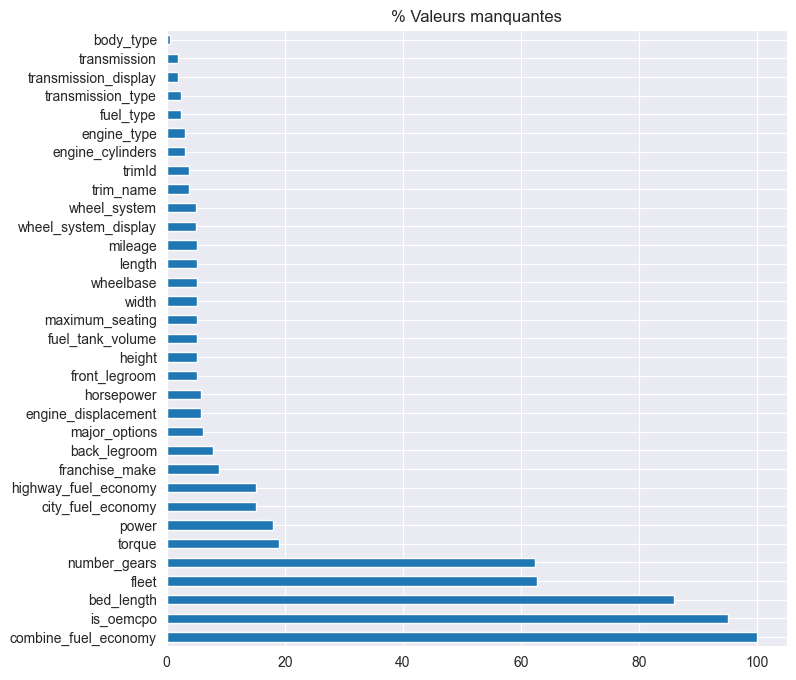

In [18]:
missing_pct.plot(kind='barh', figsize=(8, 8), title='% Valeurs manquantes')
plt.show()

*Analyse de la variable cible : Prix*

Le prix médian est de 29 134 et la moyenne de 33 263 — l'écart entre les deux indique une asymétrie à droite, confirmée par un max à 2.75M  qui tire la moyenne vers le haut. La moitié des voitures se situe entre 22k et 41k. Le min à 299 est clairement une erreur de saisie à traiter en preprocessing.

In [19]:
df["price"].describe()

count    1.814329e+06
mean     3.326311e+04
std      1.898445e+04
min      2.990000e+02
25%      2.199000e+04
50%      2.913400e+04
75%      4.096900e+04
max      2.749950e+06
Name: price, dtype: float64

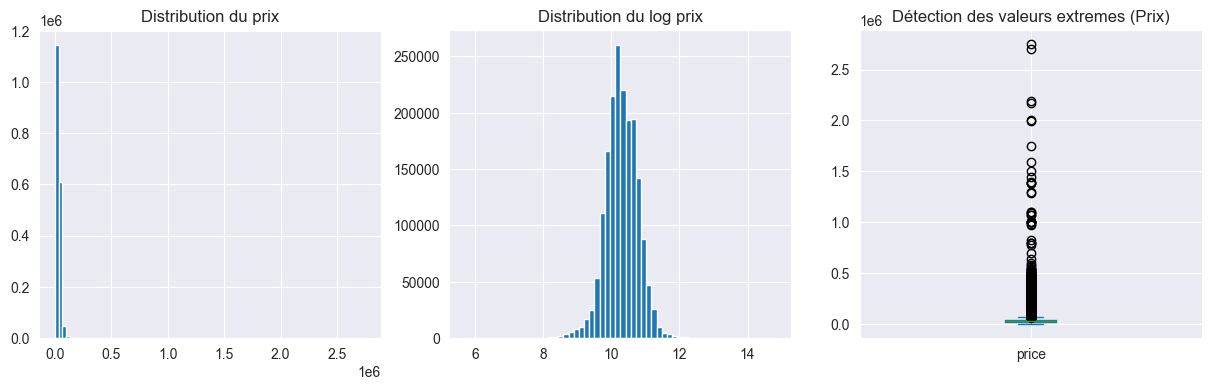

<Figure size 640x480 with 0 Axes>

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df['price'].hist(bins=80, ax=axes[0])
axes[0].set_title('Distribution du prix')

np.log1p(df['price']).hist(bins=60, ax=axes[1])
axes[1].set_title('Distribution du log prix')

df['price'].plot(kind='box', ax=axes[2])
axes[2].set_title('Détection des valeurs extremes (Prix)')
plt.show()

plt.tight_layout()
plt.show()

In [21]:
df['price'].skew()

np.float64(12.916017784351945)

La variable cible est fortement asymétrique

*Analyse des variables numériques*

Mileage : La médiane est à seulement 12 miles alors que la moyenne atteint 15 086 — le dataset est clairement dominé par des voitures quasi-neuves. La distribution sera très asymétrique, un log(mileage) sera probablement nécessaire.

Year : 50% des voitures sont concentrées entre 2018 et 2020, ce qui reflète un marché orienté véhicules récents. Le min à 1915 indique la présence de quelques voitures de collection en marge du dataset.

Daysonmarket : La médiane est de 41 jours, ce qui est raisonnable. Le max à 364 jours signale des annonces probablement abandonnées ou des véhicules très difficiles à vendre.

Number_gears : Seulement 681k valeurs sur 1.8M lignes — 63% de manquants, la variable est peu renseignée.

In [22]:
num_vars = df.select_dtypes(include=['int64','float64']).columns
df[num_vars].describe()

,back_legroom,city_fuel_economy,combine_fuel_economy,daysonmarket,engine_displacement,highway_fuel_economy,horsepower,listing_id,mileage,price,year,number_gears
count,1.672414e+06,1.541391e+06,0.0,1.814329e+06,1.708225e+06,1.541391e+06,1.708225e+06,1.814329e+06,1.722152e+06,1.814329e+06,1.814329e+06,681682.000000
mean,3.814229e+01,2.336320e+01,NaN,7.679137e+01,2.845629e+03,2.996273e+01,2.462581e+02,2.755232e+08,1.508637e+04,3.326311e+04,2.018875e+03,7.087082
std,3.011640e+00,9.428403e+00,NaN,8.561693e+01,1.301749e+03,8.058095e+00,9.084264e+01,6.593205e+06,2.907274e+04,1.898445e+04,3.130724e+00,1.403803
min,0.000000e+00,8.000000e+00,NaN,0.000000e+00,7.000000e+02,1.100000e+01,5.500000e+01,2.518374e+08,0.000000e+00,2.990000e+02,1.915000e+03,1.000000
25%,3.610000e+01,1.800000e+01,NaN,1.800000e+01,2.000000e+03,2.500000e+01,1.740000e+02,2.736020e+08,5.000000e+00,2.199000e+04,2.018000e+03,6.000000
50%,3.830000e+01,2.200000e+01,NaN,4.100000e+01,2.500000e+03,2.900000e+01,2.400000e+02,2.780568e+08,1.200000e+01,2.913400e+04,2.020000e+03,7.000000
75%,3.990000e+01,2.600000e+01,NaN,9.400000e+01,3.500000e+03,3.300000e+01,3.000000e+02,2.801670e+08,2.218100e+04,4.096900e+04,2.020000e+03,8.000000
max,5.980000e+01,1.270000e+02,NaN,3.640000e+02,8.400000e+03,1.270000e+02,9.490000e+02,2.820222e+08,1.225238e+06,2.749950e+06,2.021000e+03,10.000000


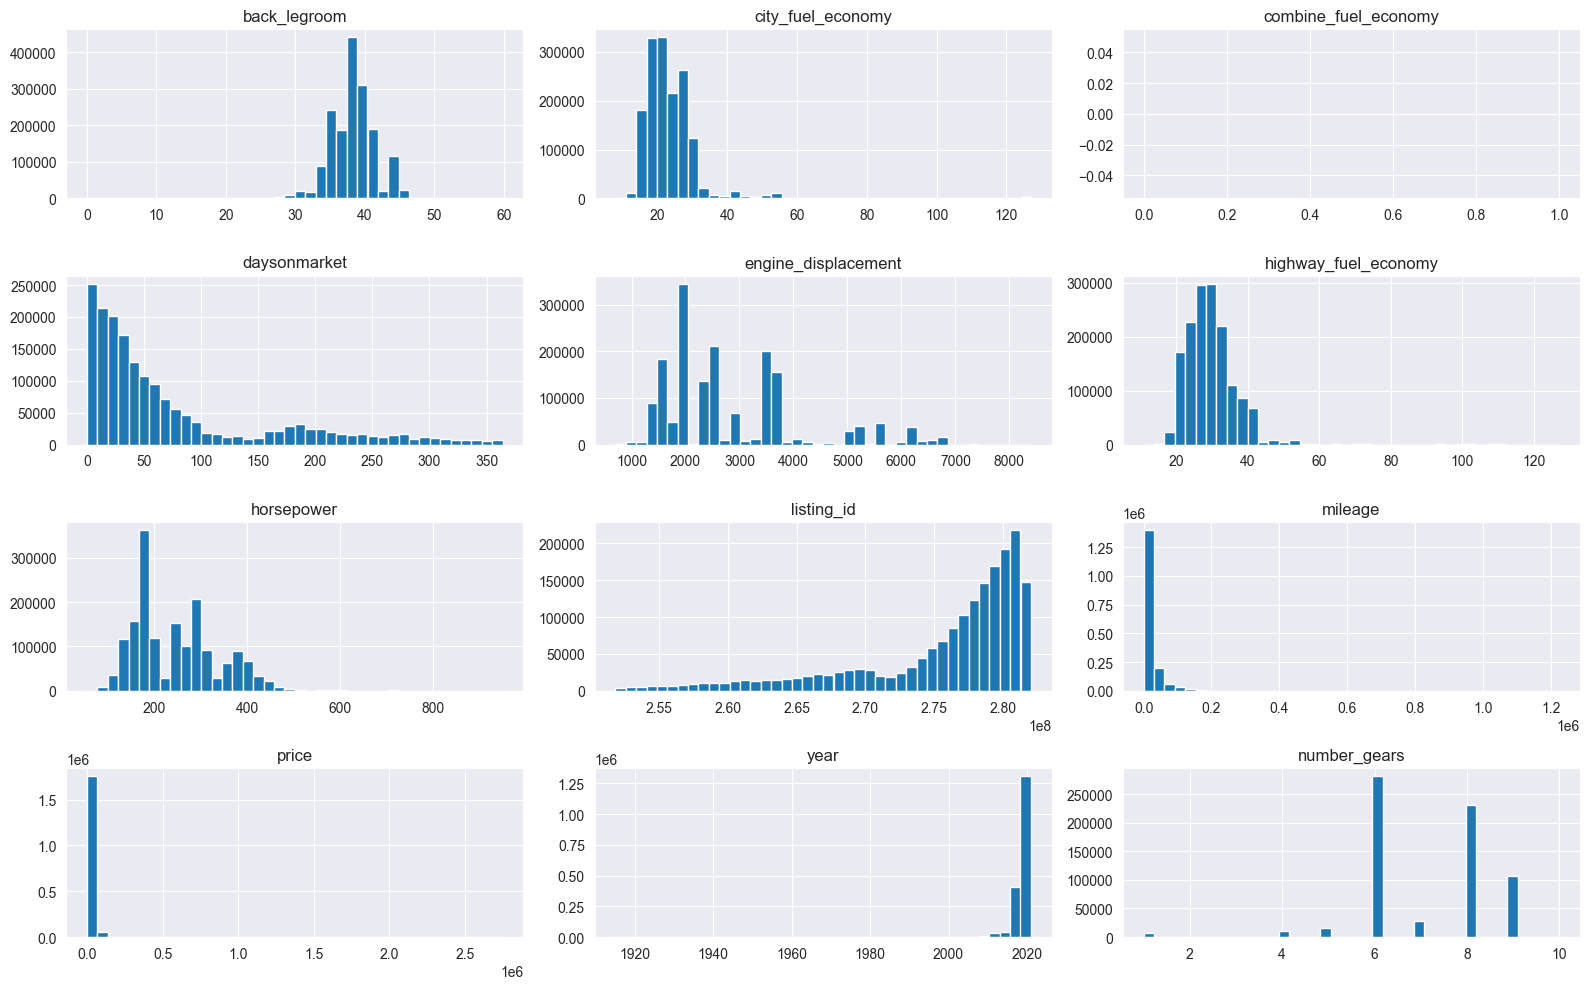

In [23]:
df[num_vars].hist(bins=40, figsize=(16, 10))
plt.tight_layout()
plt.show()

*Analyse des variables catégorielles*

In [24]:
cat_vars=df.select_dtypes(include='str').columns
for col in cat_vars:
    print(f'{col} : {df[col].nunique()} modalités | {df[col].isnull().sum()/len(df)*100:.1f}% manquants')

vin : 1814309 modalités | 0.0% manquants
bed_length : 75 modalités | 85.9% manquants
body_type : 9 modalités | 0.5% manquants
engine_cylinders : 35 modalités | 3.2% manquants
engine_type : 35 modalités | 3.2% manquants
franchise_make : 48 modalités | 8.9% manquants
front_legroom : 89 modalités | 5.1% manquants
fuel_tank_volume : 171 modalités | 5.1% manquants
fuel_type : 8 modalités | 2.4% manquants
height : 457 modalités | 5.1% manquants
length : 777 modalités | 5.1% manquants
listed_date : 369 modalités | 0.0% manquants
listing_color : 15 modalités | 0.0% manquants
major_options : 183483 modalités | 6.1% manquants
make_name : 93 modalités | 0.0% manquants
maximum_seating : 12 modalités | 5.1% manquants
model_name : 1265 modalités | 0.0% manquants
power : 1674 modalités | 17.9% manquants
sp_name : 23963 modalités | 0.0% manquants
torque : 1657 modalités | 19.0% manquants
transmission : 4 modalités | 1.9% manquants
transmission_display : 38 modalités | 1.9% manquants
trimId : 27976 mod

In [25]:
df[cat_vars].head(5)

,vin,bed_length,body_type,engine_cylinders,engine_type,franchise_make,front_legroom,fuel_tank_volume,fuel_type,height,...,torque,transmission,transmission_display,trimId,trim_name,wheel_system,wheel_system_display,wheelbase,width,transmission_type
0,SALCJ2FX1LH858117,NaN,SUV / Crossover,I4,I4,Land Rover,39.1 in,17.7 gal,Gasoline,68 in,...,"269 lb-ft @ 1,400 RPM",A,9-Speed Automatic Overdrive,t86759,S AWD,AWD,All-Wheel Drive,107.9 in,85.6 in,Automatic
1,SALRR2RV0L2433391,NaN,SUV / Crossover,V6,V6,Land Rover,39 in,23.5 gal,Gasoline,73 in,...,"332 lb-ft @ 3,500 RPM",A,8-Speed Automatic Overdrive,t86074,V6 HSE AWD,AWD,All-Wheel Drive,115 in,87.4 in,Automatic
2,SALCJ2FXXLH862327,NaN,SUV / Crossover,I4,I4,Land Rover,39.1 in,17.7 gal,Gasoline,68 in,...,"269 lb-ft @ 1,400 RPM",A,9-Speed Automatic Overdrive,t86759,S AWD,AWD,All-Wheel Drive,107.9 in,85.6 in,Automatic
3,SALYK2EX1LA261711,NaN,SUV / Crossover,I4,I4,Land Rover,40.2 in,16.6 gal,Gasoline,66.3 in,...,"269 lb-ft @ 1,200 RPM",A,8-Speed Automatic Overdrive,t85614,P250 R-Dynamic S AWD,AWD,All-Wheel Drive,113.1 in,84.4 in,Automatic
4,SALYK2EX5LA275434,NaN,SUV / Crossover,I4,I4,Land Rover,40.2 in,16.6 gal,Gasoline,66.3 in,...,"269 lb-ft @ 1,200 RPM",A,8-Speed Automatic Overdrive,t85614,P250 R-Dynamic S AWD,AWD,All-Wheel Drive,113.1 in,84.4 in,Automatic


In [26]:
#Vérifier les doublons
print(df['engine_cylinders'].equals(df['engine_type']))

True


In [27]:
print(df[['transmission', 'transmission_display']].value_counts().head(10))
print(df[['wheel_system', 'wheel_system_display']].value_counts().head(10))

transmission  transmission_display              
A             Automatic                             774844
CVT           Continuously Variable Transmission    314598
A             6-Speed Automatic                     220622
              8-Speed Automatic                     219864
              9-Speed Automatic                     103803
              6-Speed Automatic Overdrive            46996
              7-Speed Automatic                      25185
M             6-Speed Manual                          9716
A             4-Speed Automatic                       9503
              8-Speed Automatic Overdrive             9252
Name: count, dtype: int64
wheel_system  wheel_system_display
FWD           Front-Wheel Drive       762492
AWD           All-Wheel Drive         451146
4WD           Four-Wheel Drive        344947
RWD           Rear-Wheel Drive         95045
4X2           4X2                      71295
Name: count, dtype: int64


Parmi toutes variables catégorielles, plusieurs ont été écartées de l'analyse. vin et trimId sont des identifiants — leur cardinalité quasi-égale au nombre de lignes (1.8M) le confirme. "engine_type" est un doublon exact de "engine_cylinders", prouvé par equals(). "transmission" et "transmission_display" transportent la même information, mais "transmission_display" est plus riche car elle précise le nombre de vitesses. Même logique pour "wheel_system" et "wheel_system_display". Enfin, "power, torque, front_legroom, height, width" et autres sont des colonnes numériques mal typées — leurs valeurs contiennent des unités en texte et seront parsées en preprocessing.

In [28]:
identifiants = ['vin', 'trimId']
doublons = ['engine_type','wheel_system_display','transmission']
mal_typees = ['front_legroom', 'fuel_tank_volume', 'height',
              'length', 'width', 'wheelbase', 'power', 'torque', 'bed_length']
cat_gardées = ['body_type', 'fuel_type', 'transmission_display', 'wheel_system',
              'listing_color', 'maximum_seating', 'engine_cylinders',
              'franchise_make', 'make_name', 'transmission_type']

**`body_type`** — Le SUV/Crossover domine massivement avec près de 900k entrées, suivi du Sedan avec 420k. Cette spécifité reflète le marché automobile américain, très orienté grands véhicules.

**`fuel_type`** — L'essence représente environ 92% du dataset, les autres carburants (Hybrid, Diesel, Electric) sont anecdotiques.

**`transmission_display`** — La boîte automatique simple domine (~800k), suivie du CVT et des boîtes 6 et 8 vitesses. La boîte manuelle est quasi-absente.

**`listing_color`** — White, Black et UNKNOWN sont les trois couleurs les plus fréquentes. UNKNOWN représente une valeur manquante qui devra être traitée en preprocessing.

**`maximum_seating`** — Les véhicules 5 places écrasent toutes les autres catégories avec 1.2M d'entrées, ce qui confirme la dominance des berlines et SUV standard déjà observée dans `body_type`.

**`engine_cylinders`** — Le moteur 4 cylindres (I4) domine largement avec 900k véhicules, reflet d'un marché orienté motorisations accessibles et économiques. Le V6 et le V8 représentent respectivement les segments intermédiaire et premium.

**`franchise_make` vs `make_name`** — Les deux distributions sont visuellement très similaires, Ford et Chevrolet dominent dans les deux cas. Une vérification s'impose pour confirmer si elles sont redondantes.

**`transmission_type`** — L'automatique représente ~80% du dataset, le CVT ~20%, et le manuel moins de 1%.

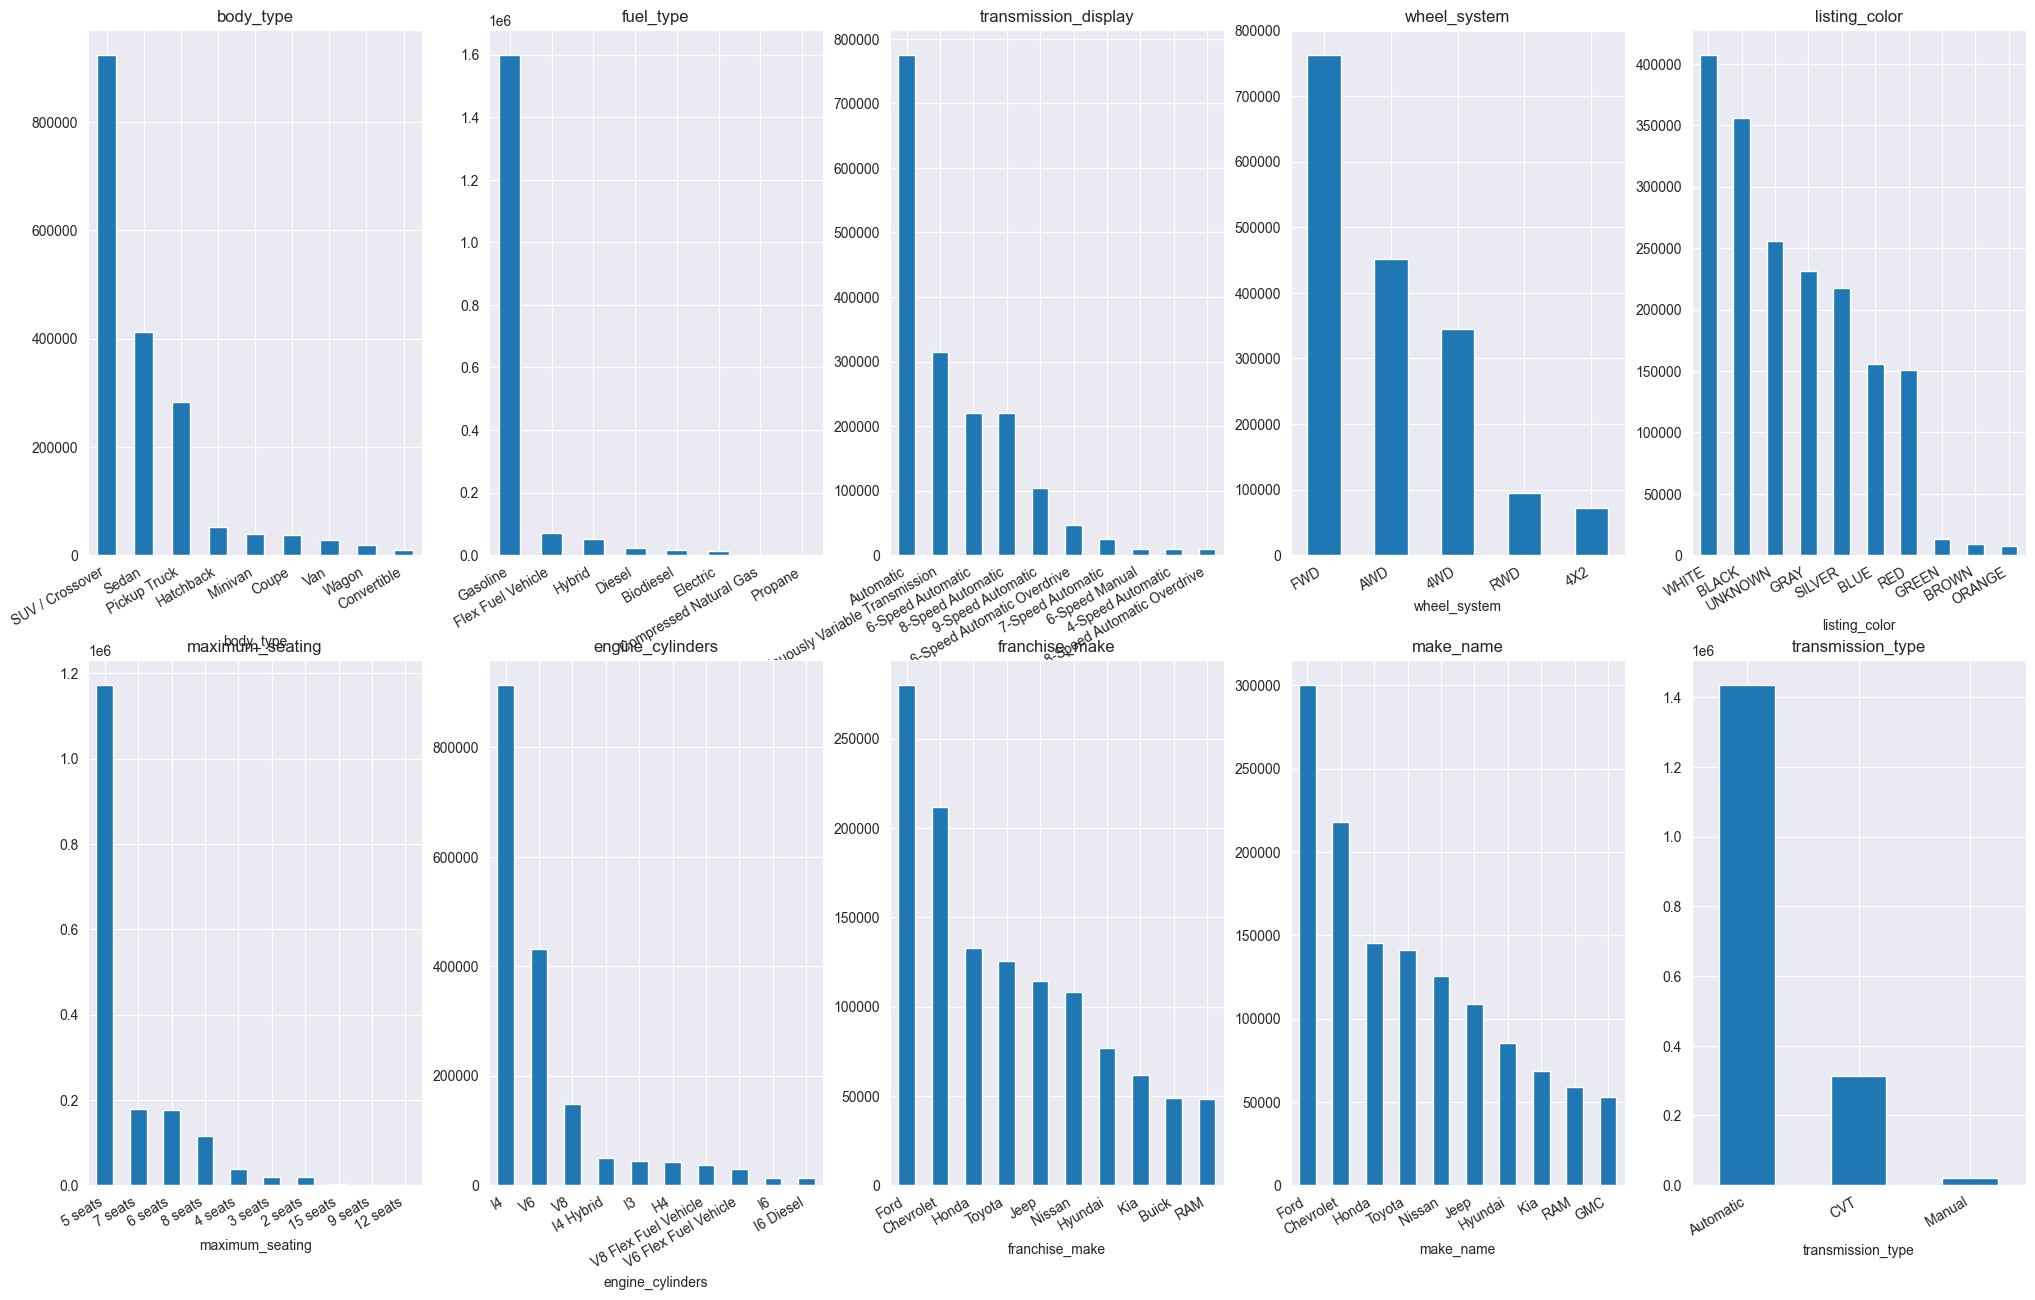

In [29]:
fig, axes = plt.subplots(2, 5, figsize=(25, 15))

for ax, col in zip(axes.flatten(), cat_gardées):
    df[col].value_counts().head(10).plot(kind='bar', ax=ax, title=col)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')

plt.show()

In [30]:
print(df[['make_name', 'franchise_make']].value_counts().head(10))

make_name  franchise_make
Ford       Ford              255853
Chevrolet  Chevrolet         179419
Honda      Honda             120305
Toyota     Toyota            112250
Nissan     Nissan             99268
Jeep       Jeep               87254
Hyundai    Hyundai            68856
Kia        Kia                54041
RAM        RAM                47993
GMC        GMC                38724
Name: count, dtype: int64


*Corrélations*

**Corrélations avec price**
"horsepower" est la variable la plus corrélée avec le prix (r=0.67) — plus un moteur est puissant, plus la voiture est chère. "engine_displacement" suit avec r=0.46, ce qui est cohérent car cylindrée et puissance vont souvent de pair. mileage affiche une corrélation négative modérée (r=-0.32) — plus une voiture a de kilomètres, moins elle vaut. "highway_fuel_economy" est aussi négativement corrélée (r=-0.31), ce type de voitures consomment plus mais coûtent plus cher. "daysonmarket" est quasi-nul (r=0.08) — le temps passé sur le marché n'explique pas le prix.

**Redondances entre variables**
"city_fuel_economy" et "highway_fuel_economy" sont quasi-parfaitement corrélées (r=0.95) — ce sont deux mesures de la même chose, on en gardera une seule en modélisation. "horsepower" et "engine_displacement" sont très fortement corrélées (r=0.83) — même problème de redondance, à surveiller pour éviter la multicolinéarité.


"mileage" et "year" sont négativement corrélées (r=-0.66) — une voiture récente a moins de kilomètres. "horsepower" et "city_fuel_economy" sont négativement corrélées (r=-0.67) — les moteurs puissants consomment plus en ville.

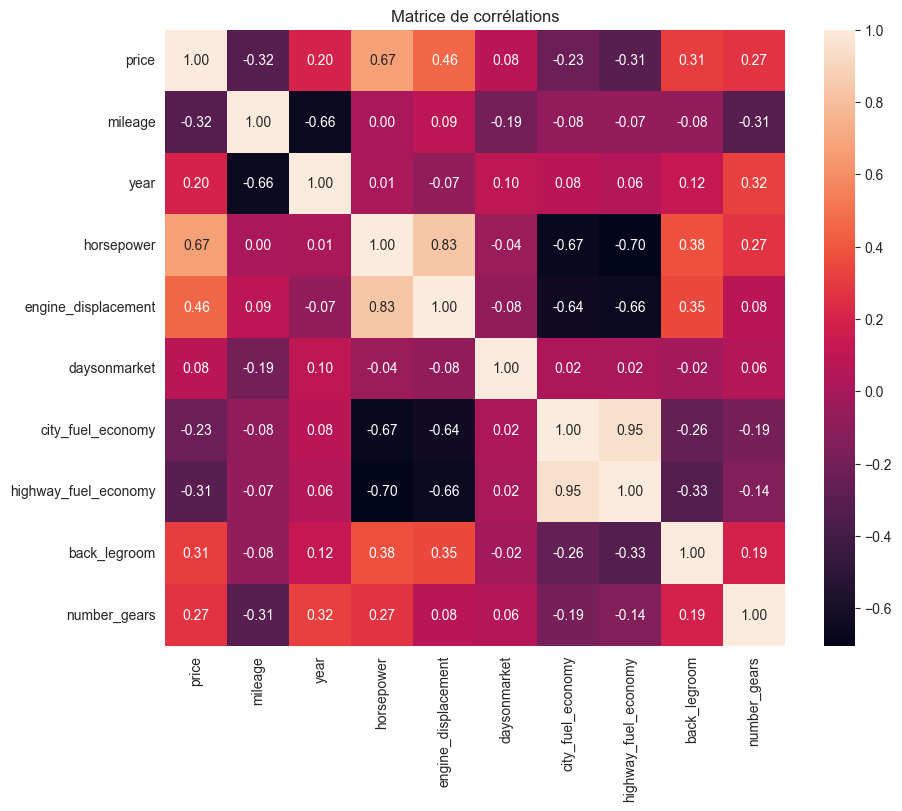

In [31]:
num_cols = ['price', 'mileage', 'year', 'horsepower', 'engine_displacement',
            'daysonmarket', 'city_fuel_economy', 'highway_fuel_economy',
            'back_legroom', 'number_gears']

corr = df[num_cols].corr()

import seaborn as sns
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f')
plt.title('Matrice de corrélations')
plt.show()

*Valeurs extremems*

**price :**  17k outliers, correspond aux voitures de luxe et aux erreurs de saisie ($299).

**mileage :** 43k outliers, dont des valeurs clairement impossibles (>500k miles). Mélange d'erreurs de saisie et de vrais véhicules très kilométrés.

**year:** 20k outliers correspondant aux voitures de collection (avant 2000). Ce sont des vrais véhicules mais atypiques par rapport au reste du dataset.

**daysonmarket:** 22k annonces restées très longtemps en ligne. Peut indiquer des prix trop élevés ou des véhicules peu attractifs.


In [32]:
from scipy import stats

num_cols = ['price', 'mileage', 'year', 'horsepower', 'engine_displacement',
            'daysonmarket', 'city_fuel_economy', 'highway_fuel_economy',
            'back_legroom', 'number_gears']

for col in num_cols:
    serie = df[col].dropna()
    mean = serie.mean()
    std = serie.std()
    z_scores = (serie - mean) / std
    outliers = z_scores[np.abs(z_scores) > 3]
    print(f'{col} : {len(outliers):,} outliers ({round(len(outliers)/len(serie)*100, 2)}%)')

price : 17,187 outliers (0.95%)
mileage : 43,362 outliers (2.52%)
year : 20,178 outliers (1.11%)
horsepower : 6,832 outliers (0.4%)
engine_displacement : 2,074 outliers (0.12%)
daysonmarket : 22,800 outliers (1.26%)
city_fuel_economy : 22,202 outliers (1.44%)
highway_fuel_economy : 10,282 outliers (0.67%)
back_legroom : 12,313 outliers (0.74%)
number_gears : 6,762 outliers (0.99%)


**2. Preprocessing**

La suppression des colonnes s'appuie sur trois critères observés durant l'EDA. Les identifiants (vin, trimId, listing_id) n'ont aucune valeur prédictive par définition.

Les doublons (engine_type, wheel_system_display, transmission) transportent exactement la même information qu'une autre colonne déjà présente.

Enfin, les colonnes à fort taux de manquants (combine_fuel_economy à 100%, bed_length à 86%, is_oemcpo à 85%, number_gears et fleet à 63%) sont écartées car la combinaison d'un taux élevé de manquants et d'une faible corrélation avec le prix ne justifie pas l'imputation, on créerait plus de bruit que de signal.

In [33]:
cols_to_drop = ['vin', 'trimId', 'listing_id',
                'engine_type', 'wheel_system_display', 'transmission',
                'combine_fuel_economy', 'bed_length', 'is_oemcpo',
                'number_gears', 'fleet']

df = df.drop(columns=cols_to_drop)

In [34]:
mal_typees = ['front_legroom', 'fuel_tank_volume', 'height',
              'length', 'width', 'wheelbase', 'power', 'torque']

df[mal_typees].head(5)

,front_legroom,fuel_tank_volume,height,length,width,wheelbase,power,torque
0,39.1 in,17.7 gal,68 in,181 in,85.6 in,107.9 in,"246 hp @ 5,500 RPM","269 lb-ft @ 1,400 RPM"
1,39 in,23.5 gal,73 in,195.1 in,87.4 in,115 in,"340 hp @ 6,500 RPM","332 lb-ft @ 3,500 RPM"
2,39.1 in,17.7 gal,68 in,181 in,85.6 in,107.9 in,"246 hp @ 5,500 RPM","269 lb-ft @ 1,400 RPM"
3,40.2 in,16.6 gal,66.3 in,188.9 in,84.4 in,113.1 in,"247 hp @ 5,500 RPM","269 lb-ft @ 1,200 RPM"
4,40.2 in,16.6 gal,66.3 in,188.9 in,84.4 in,113.1 in,"247 hp @ 5,500 RPM","269 lb-ft @ 1,200 RPM"


Ces colonnes sont des variables numériques mal typées, elles contiennent des valeurs numériques accompagnées d'unités textuelles ("in", "gal", "hp", "lb-ft") qui empêchent pandas de les interpréter correctement. L'objectif est d'extraire uniquement la partie numérique, l'unité étant constante pour toute la colonne elle n'a pas besoin d'être conservée.

In [35]:
simple_cols = ['front_legroom', 'fuel_tank_volume', 'height', 'length', 'width', 'wheelbase']

for col in simple_cols:
    df[col] = df[col].str.extract(r'([\d.]+)').astype(float)

In [36]:
df['power'] = df['power'].str.extract(r'([\d,]+)\s*hp')[0].str.replace(',', '').astype(float)
df['torque'] = df['torque'].str.extract(r'([\d,]+)\s*lb-ft')[0].str.replace(',', '').astype(float)

In [37]:
print(df[simple_cols ].dtypes)
print(df[['power', 'torque']].dtypes)

front_legroom       float64
fuel_tank_volume    float64
height              float64
length              float64
width               float64
wheelbase           float64
dtype: object
power     float64
torque    float64
dtype: object


In [38]:
#Vérification d'une redondance
print(df[['power', 'horsepower']].corr())
print(df[['power', 'horsepower']].head(10))
df = df.drop(columns=['power'])

               power  horsepower
power       1.000000    0.963955
horsepower  0.963955    1.000000
   power  horsepower
0  246.0       246.0
1  340.0       340.0
2  246.0       246.0
3  247.0       247.0
4  247.0       247.0
5  246.0       246.0
6  246.0       246.0
7  247.0       247.0
8  246.0       246.0
9  247.0       247.0


In [39]:
df.select_dtypes(include='number').columns

Index(['back_legroom', 'city_fuel_economy', 'daysonmarket',
       'engine_displacement', 'front_legroom', 'fuel_tank_volume', 'height',
       'highway_fuel_economy', 'horsepower', 'length', 'mileage', 'price',
       'torque', 'wheelbase', 'width', 'year'],
      dtype='str')

*Nettoyage des valeurs aberrantes*

**mileage > 300k miles** : Au-delà de 300k miles, les valeurs sont des erreurs de saisie.

**price < 1000** : Aucune voiture ne se vend légitimement à moins de $1000 sur un marché grand public.

In [40]:
df = df.replace([0, '--', 'UNKNOWN'], np.nan)
df = df[df['mileage'] <= 300_000]
df = df[df['price'] >= 1_000]

*Imputation des valeurs manquantes*

In [41]:
num_cols = df.select_dtypes(include='number').columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [42]:
cat_cols = df.select_dtypes(include='str').columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [43]:
df.isnull().sum().sum()

np.int64(0)

*Traitement des outliers*

La transformation logarithmique est appliquée sur price et mileage car ces deux variables présentent une forte asymétrie à droite

In [44]:
df['log_price'] = np.log1p(df['price'])
df['log_mileage'] = np.log1p(df['mileage'])

**3. Feature Engineering**

L'age de la voiture est plus informative que l'année de fabrication du véhicule. 

In [45]:
df['car_age'] = 2021 - df['year']

In [46]:
df['mileage_per_year'] = df['mileage'] / df['car_age'].replace(0, 1)

 Les marques premium ont un comportement de prix très différent du reste du marché, indépendamment des autres variables.

In [47]:
luxury_brands = ['BMW', 'Mercedes-Benz', 'Audi', 'Lexus', 'Porsche',
                 'Land Rover', 'Jaguar', 'Maserati', 'Bentley', 'Ferrari']

df['is_luxury'] = df['make_name'].isin(luxury_brands).astype(int)

*Encodage*

**One-Hot Encoding** sur "body_type", "fuel_type", "transmission_type", "wheel_system", "listing_color" — ces variables ont moins de 15 modalités et n'ont pas d'ordre logique entre elles. Un SUV n'est pas "plus" qu'une Sedan, l'essence n'est pas "plus" que le Diesel. drop_first=True supprime une modalité par variable pour éviter la multicolinéarité.

In [48]:
onehot_cols = ['body_type', 'fuel_type', 'transmission_type', 'wheel_system', 'listing_color']

encoder = OneHotEncoder(drop='first', sparse_output=False)
encoded = encoder.fit_transform(df[onehot_cols])
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(onehot_cols))

df = df.drop(columns=onehot_cols).reset_index(drop=True)
df = pd.concat([df, encoded_df], axis=1)

**Label Encoding** sur "maximum_seating" : le nombre de places a un ordre naturel et logique : 2 places < 5 places < 8 places. On peut donc encoder ordinalement sans perdre cette information.

In [49]:
seating_order = {'2 seats': 1, '3 seats': 2, '4 seats': 3, '5 seats': 4,
                 '6 seats': 5, '7 seats': 6, '8 seats': 7, '9 seats': 8,
                 '10 seats': 9, '12 seats': 10, '15 seats': 11}

df['maximum_seating'] = df['maximum_seating'].map(seating_order)

In [50]:
df.sample(10)

,back_legroom,city_fuel_economy,daysonmarket,engine_cylinders,engine_displacement,franchise_dealer,franchise_make,front_legroom,fuel_tank_volume,height,...,listing_color_GRAY,listing_color_GREEN,listing_color_ORANGE,listing_color_PINK,listing_color_PURPLE,listing_color_RED,listing_color_SILVER,listing_color_TEAL,listing_color_WHITE,listing_color_YELLOW
368152,37.3,22.0,61.0,I4,2000.0,True,Jeep,43.1,15.7,66.3,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1128328,37.3,22.0,1.0,I4,2000.0,False,Ford,40.8,17.4,64.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1446939,38.0,28.0,73.0,I4,2500.0,True,Toyota,42.1,16.0,56.9,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1106332,38.2,22.0,20.0,V6,2500.0,True,Jeep,42.0,17.1,66.1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
413859,37.5,22.0,202.0,I4,2500.0,True,Buick,40.9,17.3,66.8,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
685320,31.7,27.0,16.0,I4,2000.0,True,Toyota,43.5,13.2,61.6,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1399018,32.4,20.0,57.0,V6,3000.0,True,INFINITI,43.1,20.0,54.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
145966,38.4,22.0,263.0,V6,3500.0,True,Toyota,44.2,19.2,70.1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
273831,43.6,19.0,40.0,V6,3500.0,True,Ford,43.9,23.0,76.9,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
35995,38.3,22.0,43.0,I4,2400.0,True,Jeep,41.8,13.5,64.8,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
